In [1]:
# %%
import os
import sys
import yaml
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from collections import defaultdict

# Mount parent directory to access src modules
sys.path.append(os.path.abspath('..'))

if os.path.basename(os.getcwd()) in ['notebooks', 'scripts']:
    os.chdir('..')
    print("New Working Directory:", os.getcwd())

sns.set_theme(style="whitegrid", palette="muted")

In [2]:
# %%
configs = {
    'Classic': '../config/eap/graphgps_ba_classic.yaml',
    'MPNN': '../config/eap/graphgps_ba_mpnn.yaml',
    'MPNN_Attention': '../config/eap/graphgps_ba_mpnn_attention.yaml'
}

data = {}

for name, path in configs.items():
    if not os.path.exists(path):
        print(f"Warning: Config {path} not found.")
        continue
        
    with open(path, 'r') as f:
        config = yaml.safe_load(f)
        
    save_dir = os.path.join("..", config['experiment']['save_dir'])
    
    # Load Macros, Masks, and Micros
    try:
        macro_path = os.path.join(save_dir, 'global_macro_attributions.pt')
        mask_path = os.path.join(save_dir, 'optimal_masks.pt')
        micro_path = os.path.join(save_dir, 'micro_edges_raw.pt')
        
        data[name] = {
            'macro': torch.load(macro_path, map_location='cpu') if os.path.exists(macro_path) else {},
            'masks': torch.load(mask_path, map_location='cpu') if os.path.exists(mask_path) else {},
            'micro': torch.load(micro_path, map_location='cpu') if os.path.exists(micro_path) else []
        }
        print(f"Loaded {name} from {save_dir}")
    except Exception as e:
        print(f"Error loading {name}: {e}")

Loaded Classic from .././outputs/eap_results/ba_shapes/graphgps/classic/
Loaded MPNN from .././outputs/eap_results/ba_shapes/graphgps/only_mpnn/
Loaded MPNN_Attention from .././outputs/eap_results/ba_shapes/graphgps/mpnn_attention/


In [3]:
# %%
def get_active_non_mpnn_components(masks_dict):
    """Returns a set of active components that are NOT M, A, or U."""
    active = set()
    for comp, mask in masks_dict.items():
        if isinstance(mask, torch.Tensor):
            is_active = (mask > 0).any().item()
        else:
            is_active = mask > 0
            
        if is_active:
            if not comp.endswith(('.M', '.A', '.U')):
                active.add(comp)
    return active

active_components = {}
for name, run_data in data.items():
    if 'masks' in run_data and run_data['masks']:
        active_components[name] = get_active_non_mpnn_components(run_data['masks'])

print("--- Surviving Non-MPNN Components ---")
all_unique_comps = set.union(*active_components.values()) if active_components else set()

for comp in sorted(all_unique_comps):
    status = []
    for name in configs.keys():
        if name in active_components:
            status.append(f"{name}: {'✅' if comp in active_components[name] else '❌'}")
    print(f"{comp:<30} | {' | '.join(status)}")

--- Surviving Non-MPNN Components ---
encoder.pe_encoder             | Classic: ✅ | MPNN: ✅ | MPNN_Attention: ✅
head.0                         | Classic: ✅ | MPNN: ✅ | MPNN_Attention: ✅
head.3                         | Classic: ✅ | MPNN: ✅ | MPNN_Attention: ✅
layers.0.attn                  | Classic: ✅ | MPNN: ✅ | MPNN_Attention: ❌
layers.0.attn.A.head_0         | Classic: ❌ | MPNN: ❌ | MPNN_Attention: ✅
layers.0.attn.A.head_1         | Classic: ❌ | MPNN: ❌ | MPNN_Attention: ✅
layers.0.attn.A.head_2         | Classic: ❌ | MPNN: ❌ | MPNN_Attention: ✅
layers.0.attn.A.head_3         | Classic: ❌ | MPNN: ❌ | MPNN_Attention: ✅
layers.0.attn.A.head_4         | Classic: ❌ | MPNN: ❌ | MPNN_Attention: ✅
layers.0.attn.A.head_5         | Classic: ❌ | MPNN: ❌ | MPNN_Attention: ✅
layers.0.attn.A.head_6         | Classic: ❌ | MPNN: ❌ | MPNN_Attention: ✅
layers.0.attn.A.head_7         | Classic: ❌ | MPNN: ❌ | MPNN_Attention: ✅
layers.0.attn.M.head_0         | Classic: ❌ | MPNN: ❌ | MPNN_Attention: ✅


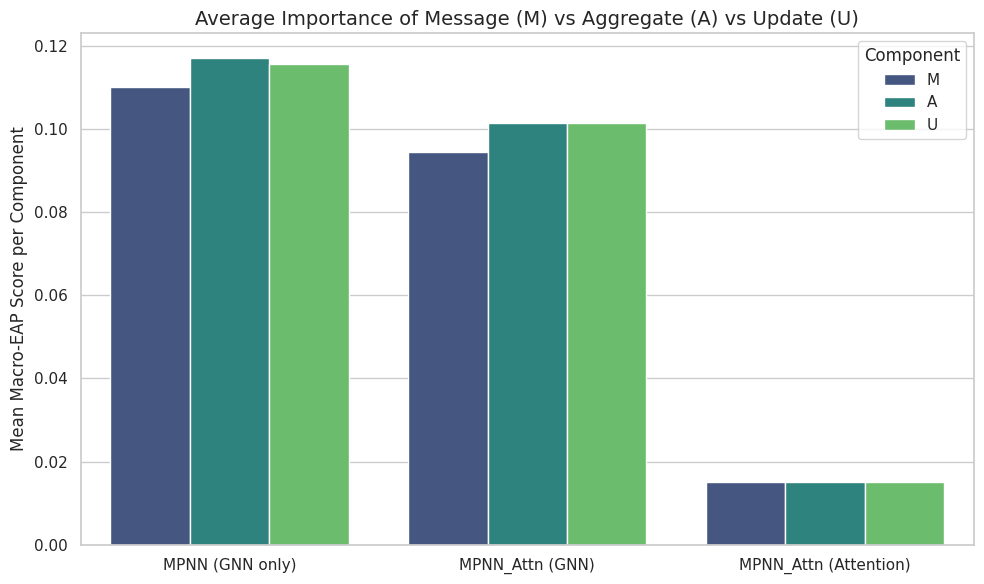

In [4]:
# %%
def aggregate_mau_scores(macro_scores):
    # Store data as [total_score, count] to calculate the mean later
    stats = {
        'GNN': {'M': [0.0, 0], 'A': [0.0, 0], 'U': [0.0, 0]}, 
        'Attention': {'M': [0.0, 0], 'A': [0.0, 0], 'U': [0.0, 0]}
    }
    
    for comp, score in macro_scores.items():
        score_val = score.item() if isinstance(score, torch.Tensor) else score
        
        comp_type = comp.split('.')[-1]
        if comp_type in ['M', 'A', 'U']:
            # GraphGPS uses 'conv' for local MPNN and 'attn' for global attention
            if 'conv' in comp.lower() or 'mpnn' in comp.lower():
                stats['GNN'][comp_type][0] += score_val
                stats['GNN'][comp_type][1] += 1
            elif 'attn' in comp.lower() or 'mha' in comp.lower() or 'multihead' in comp.lower():
                stats['Attention'][comp_type][0] += score_val
                stats['Attention'][comp_type][1] += 1
            else:
                # Fallback if names are generic
                stats['GNN'][comp_type][0] += score_val 
                stats['GNN'][comp_type][1] += 1
                
    # Calculate the mean (total_score / count)
    summary = {'GNN': {}, 'Attention': {}}
    for arch in ['GNN', 'Attention']:
        for c_type in ['M', 'A', 'U']:
            total_score, count = stats[arch][c_type]
            summary[arch][c_type] = total_score / count if count > 0 else 0.0
            
    return summary

plot_data = []

if 'MPNN' in data:
    mpnn_mau = aggregate_mau_scores(data['MPNN']['macro'])
    for comp, val in mpnn_mau['GNN'].items():
        plot_data.append({'Run': 'MPNN (GNN only)', 'Component': comp, 'Score': val})

if 'MPNN_Attention' in data:
    attn_mau = aggregate_mau_scores(data['MPNN_Attention']['macro'])
    for comp, val in attn_mau['GNN'].items():
        plot_data.append({'Run': 'MPNN_Attn (GNN)', 'Component': comp, 'Score': val})
    for comp, val in attn_mau['Attention'].items():
        plot_data.append({'Run': 'MPNN_Attn (Attention)', 'Component': comp, 'Score': val})

df_mau = pd.DataFrame(plot_data)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_mau, x='Run', y='Score', hue='Component', palette='viridis')
plt.title("Average Importance of Message (M) vs Aggregate (A) vs Update (U)", fontsize=14)
plt.ylabel("Mean Macro-EAP Score per Component")
plt.xlabel("")
plt.tight_layout()
plt.show()

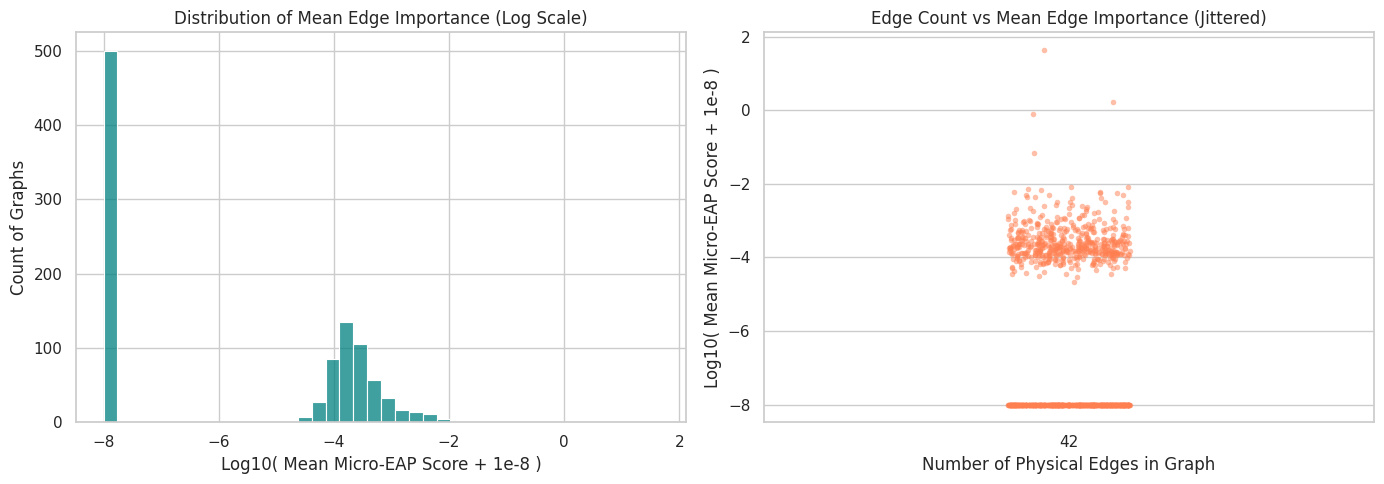

In [5]:
# %%
# We will use the MPNN_Attention run to get the richest structural data
if 'MPNN_Attention' in data and data['MPNN_Attention']['micro']:
    micro_list = data['MPNN_Attention']['micro']
    
    # 1. Calculate Mean Edge Value per Graph
    graph_means = []
    for graph_data in micro_list:
        num_physical_edges = graph_data['edge_index'].shape[1]
        
        # ONLY pick Message modules that correspond to physical structural edges
        m_scores = [
            v for k, v in graph_data['micro_scores'].items() 
            if k.endswith('.M') and v.shape == (num_physical_edges,)
        ]
        
        if m_scores:
            total_edge_scores = torch.stack(m_scores).sum(dim=0)
            graph_means.append({
                'graph_index': graph_data['graph_index'],
                'mean_edge_score': total_edge_scores.mean().item(),
                'max_edge_score': total_edge_scores.max().item(),
                'num_edges': num_physical_edges
            })
            
    df_micro = pd.DataFrame(graph_means)
    
    # ADDED: Apply Log10 scale (with small epsilon to prevent log(0) errors)
    df_micro['log_mean_score'] = np.log10(df_micro['mean_edge_score'] + 1e-8)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Use the Log-scaled scores for the histogram
    sns.histplot(df_micro['log_mean_score'], bins=40, ax=ax1, color='teal')
    ax1.set_title("Distribution of Mean Edge Importance (Log Scale)")
    ax1.set_xlabel("Log10( Mean Micro-EAP Score + 1e-8 )")
    ax1.set_ylabel("Count of Graphs")
    
    # CHANGED: Use a stripplot to add jitter so we can see overlapping dots!
    sns.stripplot(
        data=df_micro, 
        x='num_edges', 
        y='log_mean_score', 
        ax=ax2, 
        color='coral', 
        alpha=0.5, 
        jitter=True,
        size=4
    )
    
    ax2.set_title("Edge Count vs Mean Edge Importance (Jittered)")
    ax2.set_xlabel("Number of Physical Edges in Graph")
    ax2.set_ylabel("Log10( Mean Micro-EAP Score + 1e-8 )")
    
    plt.tight_layout()
    plt.show()
else:
    print("Micro-EAP data not found for MPNN_Attention.")

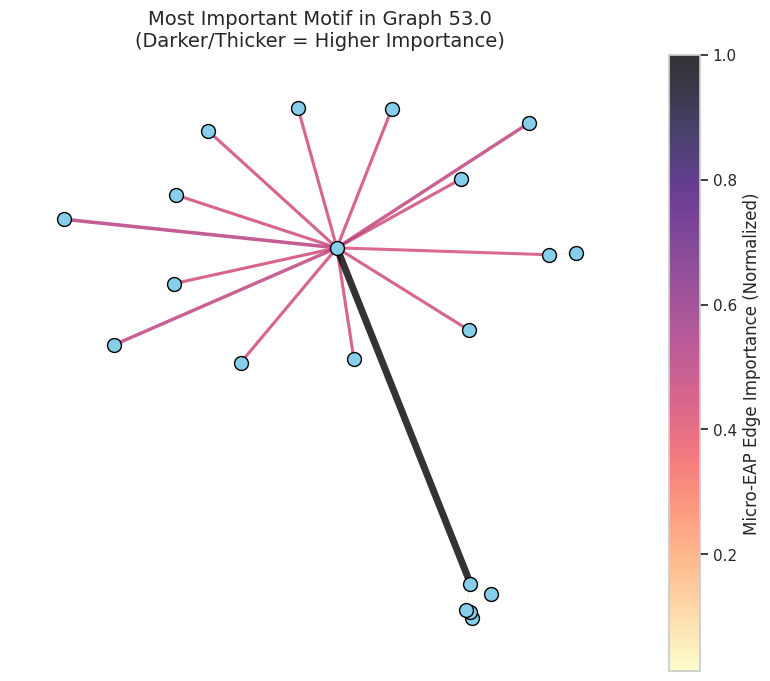

In [6]:
# %%
if 'MPNN' in data and data['MPNN']['micro']:
    micro_list = data['MPNN']['micro']
    
    # Find the graph with the highest *maximum* edge score
    best_graph_idx = df_micro.loc[df_micro['max_edge_score'].idxmax()]['graph_index']
    target_data = next(g for g in micro_list if g['graph_index'] == best_graph_idx)
    
    edge_index = target_data['edge_index'].numpy()
    num_physical_edges = edge_index.shape[1]
    
    # Aggregate M scores across layers for this specific graph (FILTERED by physical shape)
    m_scores = [
        v for k, v in target_data['micro_scores'].items() 
        if k.endswith('.M') and v.shape == (num_physical_edges,)
    ]
    
    if m_scores:
        edge_weights = torch.stack(m_scores).sum(dim=0).numpy()
        
        # Normalize weights for plotting
        edge_weights_norm = (edge_weights - edge_weights.min()) / (edge_weights.max() - edge_weights.min() + 1e-8)
        
        # Create NetworkX Graph
        G = nx.Graph() # Undirected for BA shapes
        for i in range(num_physical_edges):
            src, dst = edge_index[0, i], edge_index[1, i]
            # PyG edges are directed, so we average weights if we add undirected edges
            if G.has_edge(src, dst):
                G[src][dst]['weight'] = max(G[src][dst]['weight'], edge_weights_norm[i])
            else:
                G.add_edge(src, dst, weight=edge_weights_norm[i])
                
        edges = G.edges(data=True)
        weights = [d['weight'] * 5 for u, v, d in edges] # Scale for thickness
        colors = [d['weight'] for u, v, d in edges]
        
        plt.figure(figsize=(10, 8))
        # Kamada-Kawai usually spaces BA-shapes well to reveal the houses
        pos = nx.kamada_kawai_layout(G) 
        
        nx.draw_networkx_nodes(G, pos, node_size=100, node_color='skyblue', edgecolors='black')
        
        edges_drawn = nx.draw_networkx_edges(
            G, pos, 
            width=weights, 
            edge_color=colors, 
            edge_cmap=plt.cm.magma_r, 
            alpha=0.8
        )
        
        plt.colorbar(edges_drawn, label="Micro-EAP Edge Importance (Normalized)")
        plt.title(f"Most Important Motif in Graph {best_graph_idx}\n(Darker/Thicker = Higher Importance)", fontsize=14)
        plt.axis("off")
        plt.show()
    else:
        print(f"No valid 1D message scores found for Graph {best_graph_idx}.")

In [7]:
# %%
if 'MPNN' in data and data['MPNN']['micro']:
    micro_list_mpnn = data['MPNN']['micro']
    
    # 1. Build DataFrame specifically for MPNN
    graph_means_mpnn = []
    for graph_data in micro_list_mpnn:
        num_physical_edges = graph_data['edge_index'].shape[1]
        
        # Filter for 1D structural Message modules
        m_scores = [
            v for k, v in graph_data['micro_scores'].items() 
            if k.endswith('.M') and v.shape == (num_physical_edges,)
        ]
        
        if m_scores:
            total_edge_scores = torch.stack(m_scores).sum(dim=0)
            graph_means_mpnn.append({
                'graph_index': graph_data['graph_index'],
                'mean_edge_score': total_edge_scores.mean().item(),
                'std_edge_score': total_edge_scores.std().item(),
                'max_edge_score': total_edge_scores.max().item(),
                'min_edge_score': total_edge_scores.min().item(),
                'num_edges': num_physical_edges
            })
            
    df_micro_mpnn = pd.DataFrame(graph_means_mpnn)
    
    print("--- Summary Statistics for MPNN Micro-EAP Edge Scores ---")
    display(df_micro_mpnn.describe())
    
    print("\n--- Top 5 Graphs with Highest Maximum Edge Score ---")
    display(df_micro_mpnn.sort_values(by='max_edge_score', ascending=False).head())
else:
    print("Micro-EAP data not found for MPNN.")

--- Summary Statistics for MPNN Micro-EAP Edge Scores ---


,graph_index,mean_edge_score,std_edge_score,max_edge_score,min_edge_score,num_edges
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1000.0
mean,499.500000,0.053572,0.038401,0.174848,2.665731e-03,42.0
std,288.819436,1.598036,1.084365,4.795795,7.068005e-02,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000e+00,42.0
25%,249.750000,0.000000,0.000000,0.000000,0.000000e+00,42.0
50%,499.500000,0.000011,0.000017,0.000070,6.143140e-08,42.0
75%,749.250000,0.000209,0.000235,0.001092,5.233347e-06,42.0
max,999.000000,50.499012,34.179298,150.829727,2.211394e+00,42.0



--- Top 5 Graphs with Highest Maximum Edge Score ---


,graph_index,mean_edge_score,std_edge_score,max_edge_score,min_edge_score,num_edges
53,53,50.499012,34.179298,150.829727,2.211394,42
115,115,1.630481,2.458324,13.368689,0.289653,42
180,180,1.105276,1.369247,8.878964,0.153652,42
136,136,0.069446,0.054948,0.151629,0.002851,42
340,340,0.007395,0.012050,0.071492,0.000448,42


/tmp/ipykernel_17240/3530333265.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 0.96])


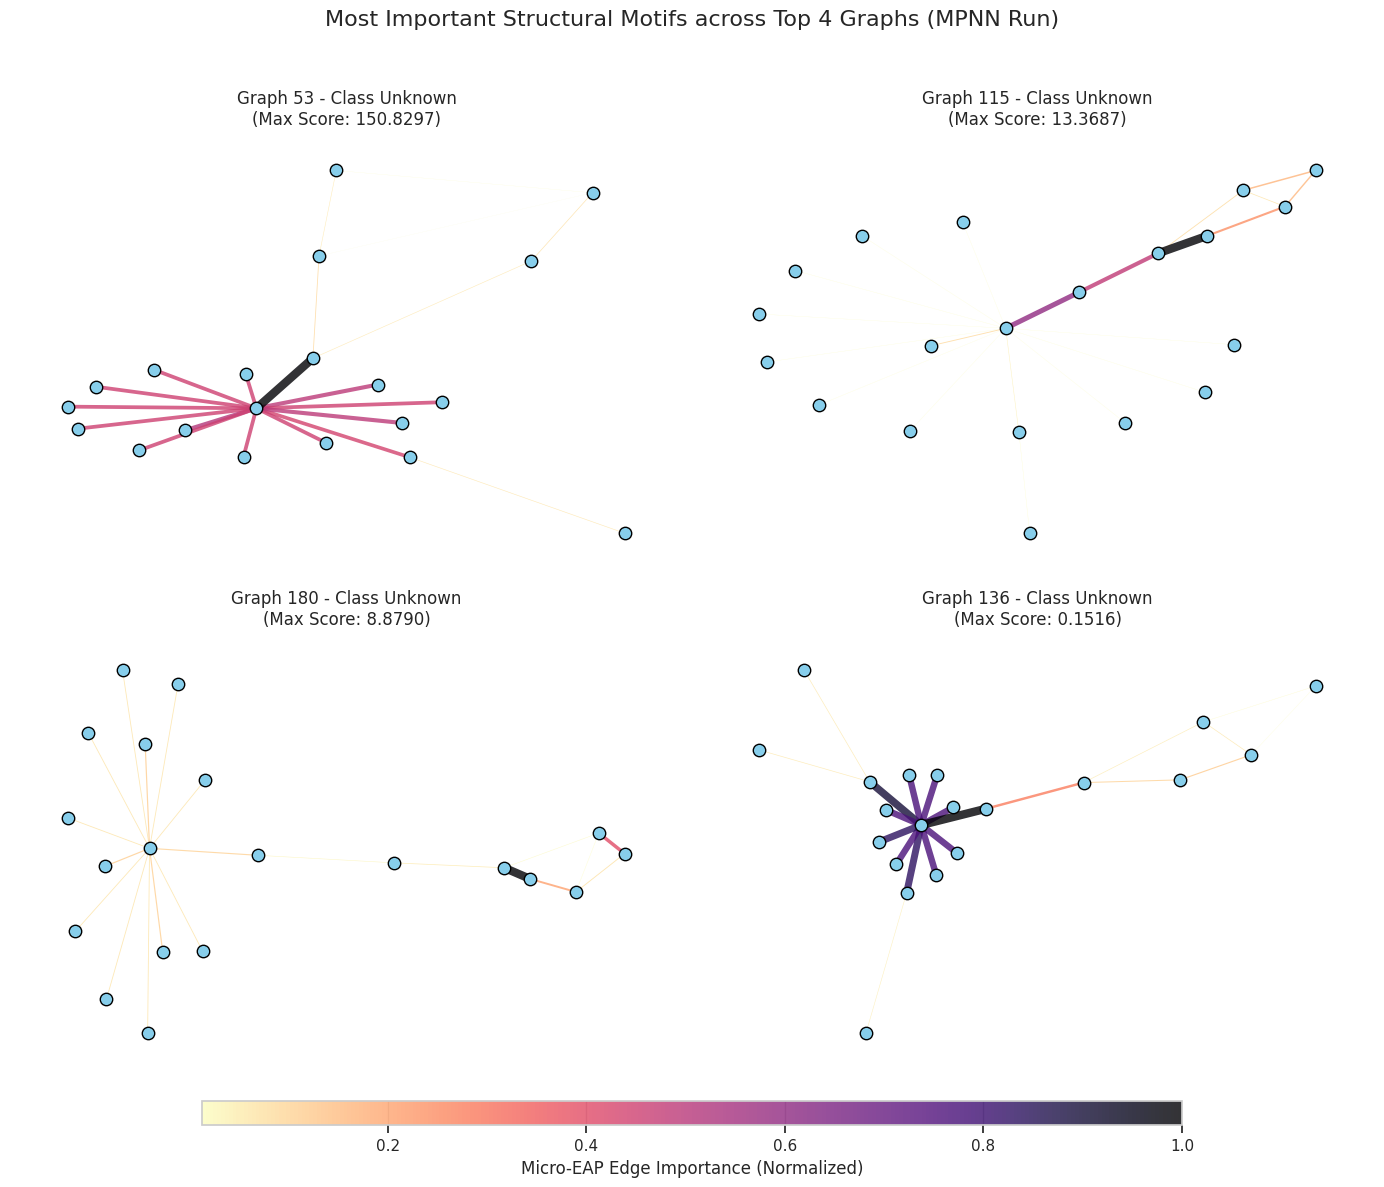

In [8]:
# %%
if 'MPNN' in data and data['MPNN']['micro'] and not df_micro_mpnn.empty:
    # Let's plot the top 4 graphs with the most important structural signals
    top_4_indices = df_micro_mpnn.sort_values(by='max_edge_score', ascending=False).head(4)['graph_index'].values
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    
    for ax_idx, g_idx in enumerate(top_4_indices):
        target_data = next(g for g in micro_list_mpnn if g['graph_index'] == g_idx)
        edge_index = target_data['edge_index'].numpy()
        num_physical_edges = edge_index.shape[1]
        
        # --- NEW: Extract the Graph Label ---
        # First, try to get it from the dataset we loaded in Cell 9
        if 'df_labels' in locals():
            label = df_labels.loc[df_labels['graph_index'] == g_idx, 'label'].iloc[0]
        else:
            # Fallback: check if it's saved inside the micro_scores data directly
            y_val = target_data.get('y', target_data.get('label', 'Unknown'))
            if isinstance(y_val, torch.Tensor):
                label = y_val.item() if y_val.numel() == 1 else y_val[0].item()
            else:
                label = y_val
        # ------------------------------------
        
        # Filter and Aggregate
        m_scores = [
            v for k, v in target_data['micro_scores'].items() 
            if k.endswith('.M') and v.shape == (num_physical_edges,)
        ]
        
        if m_scores:
            edge_weights = torch.stack(m_scores).sum(dim=0).numpy()
            # Normalize weights for plotting
            edge_weights_norm = (edge_weights - edge_weights.min()) / (edge_weights.max() - edge_weights.min() + 1e-8)
            
            # Build NetworkX Graph
            G = nx.Graph() 
            for i in range(num_physical_edges):
                src, dst = edge_index[0, i], edge_index[1, i]
                if G.has_edge(src, dst):
                    G[src][dst]['weight'] = max(G[src][dst]['weight'], edge_weights_norm[i])
                else:
                    G.add_edge(src, dst, weight=edge_weights_norm[i])
                    
            edges = G.edges(data=True)
            # Make the most important edges even thicker to stand out
            weights = [d['weight'] * 6 for u, v, d in edges] 
            colors = [d['weight'] for u, v, d in edges]
            
            # Use spring_layout with high 'k' to push nodes apart
            pos = nx.spring_layout(G, k=0.5, iterations=200, seed=42)
            
            nx.draw_networkx_nodes(G, pos, ax=axes[ax_idx], node_size=80, node_color='skyblue', edgecolors='black')
            
            edges_drawn = nx.draw_networkx_edges(
                G, pos, ax=axes[ax_idx],
                width=weights, 
                edge_color=colors, 
                edge_cmap=plt.cm.magma_r, 
                alpha=0.8
            )
            
            # CHANGED: Added "Class {label}" to the title
            axes[ax_idx].set_title(f"Graph {g_idx} - Class {label}\n(Max Score: {df_micro_mpnn[df_micro_mpnn['graph_index']==g_idx]['max_edge_score'].iloc[0]:.4f})", fontsize=12)
            axes[ax_idx].axis("off")
            
            # Add a single colorbar for all subplots based on the first plot
            if ax_idx == 0:
                cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.02])  # [left, bottom, width, height]
                fig.colorbar(edges_drawn, cax=cbar_ax, orientation='horizontal', label="Micro-EAP Edge Importance (Normalized)")

    fig.suptitle("Most Important Structural Motifs across Top 4 Graphs (MPNN Run)", fontsize=16)
    # Adjust layout to make room for colorbar at the bottom
    plt.tight_layout(rect=[0, 0.08, 1, 0.96]) 
    plt.show()
else:
    print("Could not generate plots. Missing MPNN data.")

/tmp/ipykernel_17240/1082915947.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 0.96])


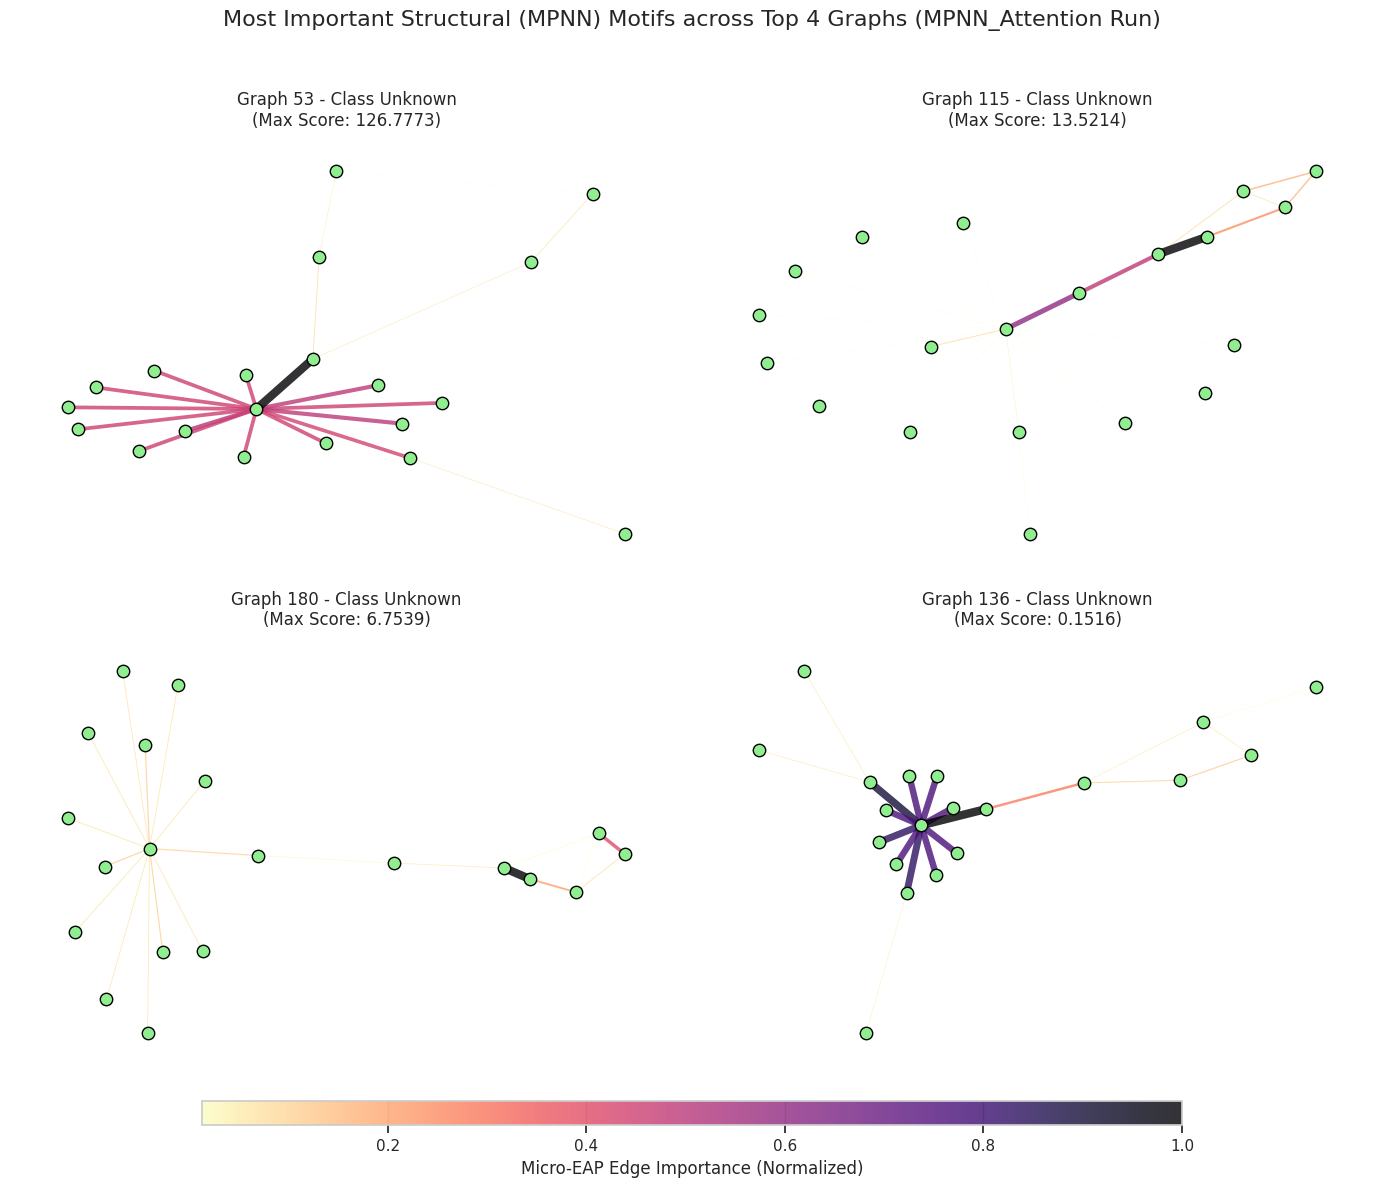

In [9]:
# %%
if 'MPNN' in data and data['MPNN']['micro'] and not df_micro.empty:
    # Let's plot the top 4 graphs with the most important structural signals in the MPNN_Attention run
    top_4_indices = df_micro.sort_values(by='max_edge_score', ascending=False).head(4)['graph_index'].values
    
    micro_list_attn = data['MPNN']['micro']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    
    for ax_idx, g_idx in enumerate(top_4_indices):
        target_data = next(g for g in micro_list_attn if g['graph_index'] == g_idx)
        edge_index = target_data['edge_index'].numpy()
        num_physical_edges = edge_index.shape[1]
        
        # --- Extract the Graph Label ---
        if 'df_labels' in locals():
            label = df_labels.loc[df_labels['graph_index'] == g_idx, 'label'].iloc[0]
        else:
            # Fallback: check if it's saved inside the micro_scores data directly
            y_val = target_data.get('y', target_data.get('label', 'Unknown'))
            if isinstance(y_val, torch.Tensor):
                label = y_val.item() if y_val.numel() == 1 else y_val[0].item()
            else:
                label = y_val
        # ------------------------------------
        
        # Filter and Aggregate ONLY local MPNN structural messages (1D tensors)
        m_scores = [
            v for k, v in target_data['micro_scores'].items() 
            if k.endswith('.M') and v.shape == (num_physical_edges,)
        ]
        
        if m_scores:
            edge_weights = torch.stack(m_scores).sum(dim=0).numpy()
            # Normalize weights for plotting
            edge_weights_norm = (edge_weights - edge_weights.min()) / (edge_weights.max() - edge_weights.min() + 1e-8)
            
            # Build NetworkX Graph
            G = nx.Graph() 
            for i in range(num_physical_edges):
                src, dst = edge_index[0, i], edge_index[1, i]
                if G.has_edge(src, dst):
                    G[src][dst]['weight'] = max(G[src][dst]['weight'], edge_weights_norm[i])
                else:
                    G.add_edge(src, dst, weight=edge_weights_norm[i])
                    
            edges = G.edges(data=True)
            # Make the most important edges even thicker to stand out
            weights = [d['weight'] * 6 for u, v, d in edges] 
            colors = [d['weight'] for u, v, d in edges]
            
            # Use spring_layout with high 'k' to push nodes apart
            pos = nx.spring_layout(G, k=0.5, iterations=200, seed=42)
            
            nx.draw_networkx_nodes(G, pos, ax=axes[ax_idx], node_size=80, node_color='lightgreen', edgecolors='black')
            
            edges_drawn = nx.draw_networkx_edges(
                G, pos, ax=axes[ax_idx],
                width=weights, 
                edge_color=colors, 
                edge_cmap=plt.cm.magma_r, 
                alpha=0.8
            )
            
            axes[ax_idx].set_title(f"Graph {g_idx} - Class {label}\n(Max Score: {df_micro[df_micro['graph_index']==g_idx]['max_edge_score'].iloc[0]:.4f})", fontsize=12)
            axes[ax_idx].axis("off")
            
            # Add a single colorbar for all subplots based on the first plot
            if ax_idx == 0:
                cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.02])  # [left, bottom, width, height]
                fig.colorbar(edges_drawn, cax=cbar_ax, orientation='horizontal', label="Micro-EAP Edge Importance (Normalized)")

    fig.suptitle("Most Important Structural (MPNN) Motifs across Top 4 Graphs (MPNN_Attention Run)", fontsize=16)
    # Adjust layout to make room for colorbar at the bottom
    plt.tight_layout(rect=[0, 0.08, 1, 0.96]) 
    plt.show()
else:
    print("Could not generate plots. Missing MPNN_Attention data.")

/tmp/ipykernel_17240/4095437516.py:81: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 0.96])


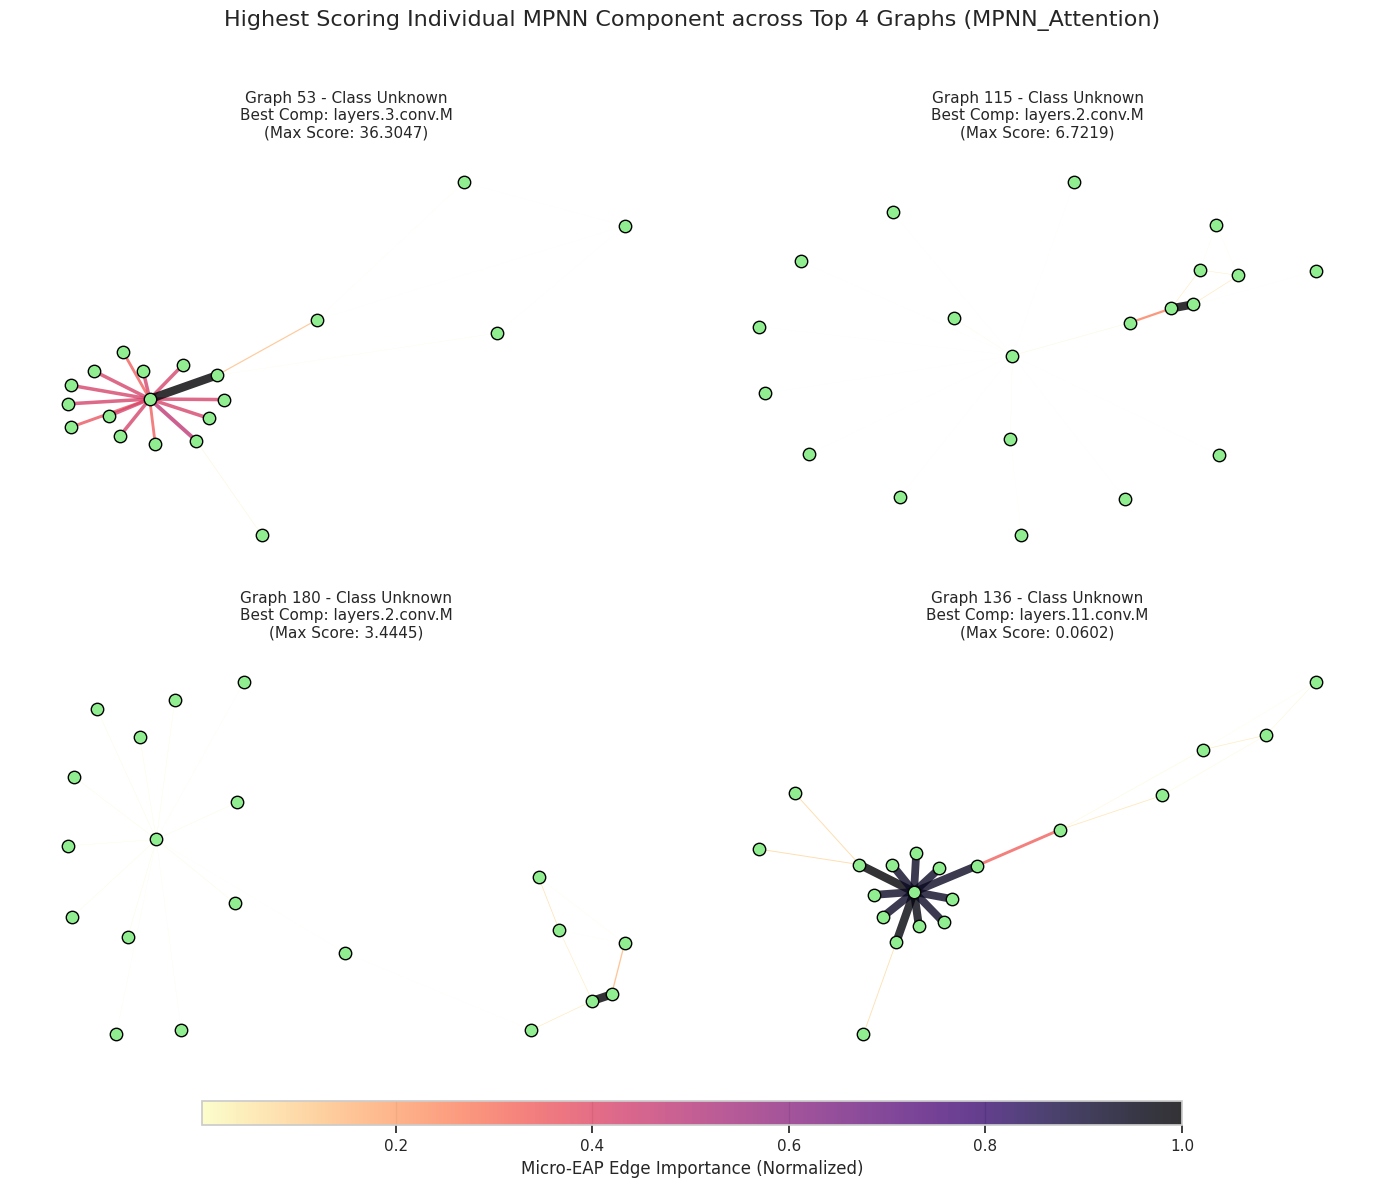

In [10]:
# %%
if 'MPNN_Attention' in data and data['MPNN_Attention']['micro'] and not df_micro.empty:
    # Let's plot the top 4 graphs with the most important structural signals in the MPNN_Attention run
    top_4_indices = df_micro.sort_values(by='max_edge_score', ascending=False).head(4)['graph_index'].values
    
    micro_list_attn = data['MPNN_Attention']['micro']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    
    for ax_idx, g_idx in enumerate(top_4_indices):
        target_data = next(g for g in micro_list_attn if g['graph_index'] == g_idx)
        edge_index = target_data['edge_index'].numpy()
        num_physical_edges = edge_index.shape[1]
        
        # --- Extract the Graph Label ---
        if 'df_labels' in locals():
            label = df_labels.loc[df_labels['graph_index'] == g_idx, 'label'].iloc[0]
        else:
            # Fallback: check if it's saved inside the micro_scores data directly
            y_val = target_data.get('y', target_data.get('label', 'Unknown'))
            if isinstance(y_val, torch.Tensor):
                label = y_val.item() if y_val.numel() == 1 else y_val[0].item()
            else:
                label = y_val
        # ------------------------------------

        # Filter for ONLY local MPNN structural messages (1D tensors)
        m_components = {
            k: v for k, v in target_data['micro_scores'].items() 
            if k.endswith('.M') and v.shape == (num_physical_edges,)
        }
        
        if m_components:
            # --- NEW: Find the SINGLE component with the highest peak score ---
            best_comp_name = max(m_components.keys(), key=lambda k: m_components[k].max().item())
            edge_weights = m_components[best_comp_name].numpy()
            # ----------------------------------------------------------------
            
            # Normalize weights for plotting
            edge_weights_norm = (edge_weights - edge_weights.min()) / (edge_weights.max() - edge_weights.min() + 1e-8)
            
            # Build NetworkX Graph
            G = nx.Graph() 
            for i in range(num_physical_edges):
                src, dst = edge_index[0, i], edge_index[1, i]
                if G.has_edge(src, dst):
                    G[src][dst]['weight'] = max(G[src][dst]['weight'], edge_weights_norm[i])
                else:
                    G.add_edge(src, dst, weight=edge_weights_norm[i])
                    
            edges = G.edges(data=True)
            # Make the most important edges even thicker to stand out
            weights = [d['weight'] * 6 for u, v, d in edges] 
            colors = [d['weight'] for u, v, d in edges]
            
            # Use spring_layout with high 'k' to push nodes apart
            pos = nx.spring_layout(G, k=0.5, iterations=200, seed=42)
            
            nx.draw_networkx_nodes(G, pos, ax=axes[ax_idx], node_size=80, node_color='lightgreen', edgecolors='black')
            
            edges_drawn = nx.draw_networkx_edges(
                G, pos, ax=axes[ax_idx],
                width=weights, 
                edge_color=colors, 
                edge_cmap=plt.cm.magma_r, 
                alpha=0.8
            )
            
            # CHANGED: Show the winning component name and its true raw score in the title
            axes[ax_idx].set_title(f"Graph {g_idx} - Class {label}\nBest Comp: {best_comp_name}\n(Max Score: {edge_weights.max():.4f})", fontsize=11)
            axes[ax_idx].axis("off")
            
            # Add a single colorbar for all subplots based on the first plot
            if ax_idx == 0:
                cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.02])  # [left, bottom, width, height]
                fig.colorbar(edges_drawn, cax=cbar_ax, orientation='horizontal', label="Micro-EAP Edge Importance (Normalized)")

    fig.suptitle("Highest Scoring Individual MPNN Component across Top 4 Graphs (MPNN_Attention)", fontsize=16)
    # Adjust layout to make room for colorbar at the bottom
    plt.tight_layout(rect=[0, 0.08, 1, 0.96]) 
    plt.show()
else:
    print("Could not generate plots. Missing MPNN_Attention data.")

In [11]:
import re
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

# %%
if 'MPNN_Attention' in data and data['MPNN_Attention']['micro'] and not df_micro.empty:
    # Pick the absolute top graph to make our animation
    top_g_idx = df_micro.sort_values(by='max_edge_score', ascending=False).iloc[0]['graph_index']
    
    micro_list_attn = data['MPNN_Attention']['micro']
    target_data = next(g for g in micro_list_attn if g['graph_index'] == top_g_idx)
    
    edge_index = target_data['edge_index'].numpy()
    num_physical_edges = edge_index.shape[1]
    
    # --- 1. Extract and Sort Layer Components ---
    layer_pattern = re.compile(r'layers\.(\d+)\.conv\.M')
    
    layer_scores = {}
    for k, v in target_data['micro_scores'].items():
        match = layer_pattern.match(k)
        if match and v.shape == (num_physical_edges,):
            layer_idx = int(match.group(1))
            layer_scores[layer_idx] = v.numpy()
            
    if not layer_scores:
        print("No 'layers.X.conv.M' components found to plot.")
    else:
        sorted_layers = sorted(layer_scores.keys())
        num_layers = len(sorted_layers)
        
        # --- 2. GLOBAL NORMALIZATION ---
        all_scores = np.concatenate(list(layer_scores.values()))
        global_min = all_scores.min()
        global_max = all_scores.max()
        
        print(f"Generating Interactive Animation for Graph {top_g_idx} across {num_layers} layers...")
        
        # --- 3. Setup Figure and Base Graph ---
        fig, ax = plt.subplots(figsize=(7, 7))
        
        # Setup colorbar (we attach it to a dummy object just so it renders once)
        sm = plt.cm.ScalarMappable(cmap=plt.cm.magma_r, norm=plt.Normalize(vmin=0, vmax=1))
        sm._A = []  
        cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.046, pad=0.04)
        cbar.set_label("Micro-EAP Edge Importance (Globally Normalized)")

        # Build base NetworkX Graph topology
        G_base = nx.Graph()
        for i in range(num_physical_edges):
            G_base.add_edge(edge_index[0, i], edge_index[1, i])
            
        pos = nx.spring_layout(G_base, k=0.5, iterations=200, seed=42)
        
        # --- 4. Animation Update Function ---
        def update(frame):
            ax.clear()
            l_idx = sorted_layers[frame]
            raw_weights = layer_scores[l_idx]
            
            # Normalize using the GLOBAL min/max
            norm_weights = (raw_weights - global_min) / (global_max - global_min + 1e-8)
            
            # Reset weights to 0 for the new frame
            for u, v in G_base.edges():
                G_base[u][v]['weight'] = 0.0
                
            # Update edge weights in the graph for this specific layer
            for i, (u, v) in enumerate(zip(edge_index[0], edge_index[1])):
                if G_base.has_edge(u, v):
                    current_weight = G_base[u][v].get('weight', 0.0)
                    G_base[u][v]['weight'] = max(current_weight, norm_weights[i])
            
            edges = G_base.edges(data=True)
            weights = [d['weight'] * 6 for u, v, d in edges]
            colors = [d['weight'] for u, v, d in edges]
            
            nx.draw_networkx_nodes(G_base, pos, ax=ax, node_size=80, node_color='lightgreen', edgecolors='black')
            
            nx.draw_networkx_edges(
                G_base, pos, ax=ax,
                width=weights, 
                edge_color=colors, 
                edge_cmap=plt.cm.magma_r, 
                edge_vmin=0.0, edge_vmax=1.0, 
                alpha=0.8
            )
            
            ax.set_title(f"Information Routing: Graph {top_g_idx}\nLayer {l_idx} (Local Max Score: {raw_weights.max():.4f})", fontsize=14)
            ax.axis("off")
            
        # --- 5. Generate and Display Animation ---
        # Create the animation (interval is ms between frames if playing automatically)
        anim = FuncAnimation(fig, update, frames=num_layers, interval=1000, repeat=False)
        
        # Close the static figure so it doesn't print a blank plot above the animation
        plt.close(fig)
        
        # Display as an interactive Javascript HTML player!
        display(HTML(anim.to_jshtml()))
else:
    print("Could not generate animation. Missing MPNN_Attention data.")

Generating Interactive Animation for Graph 53.0 across 16 layers...


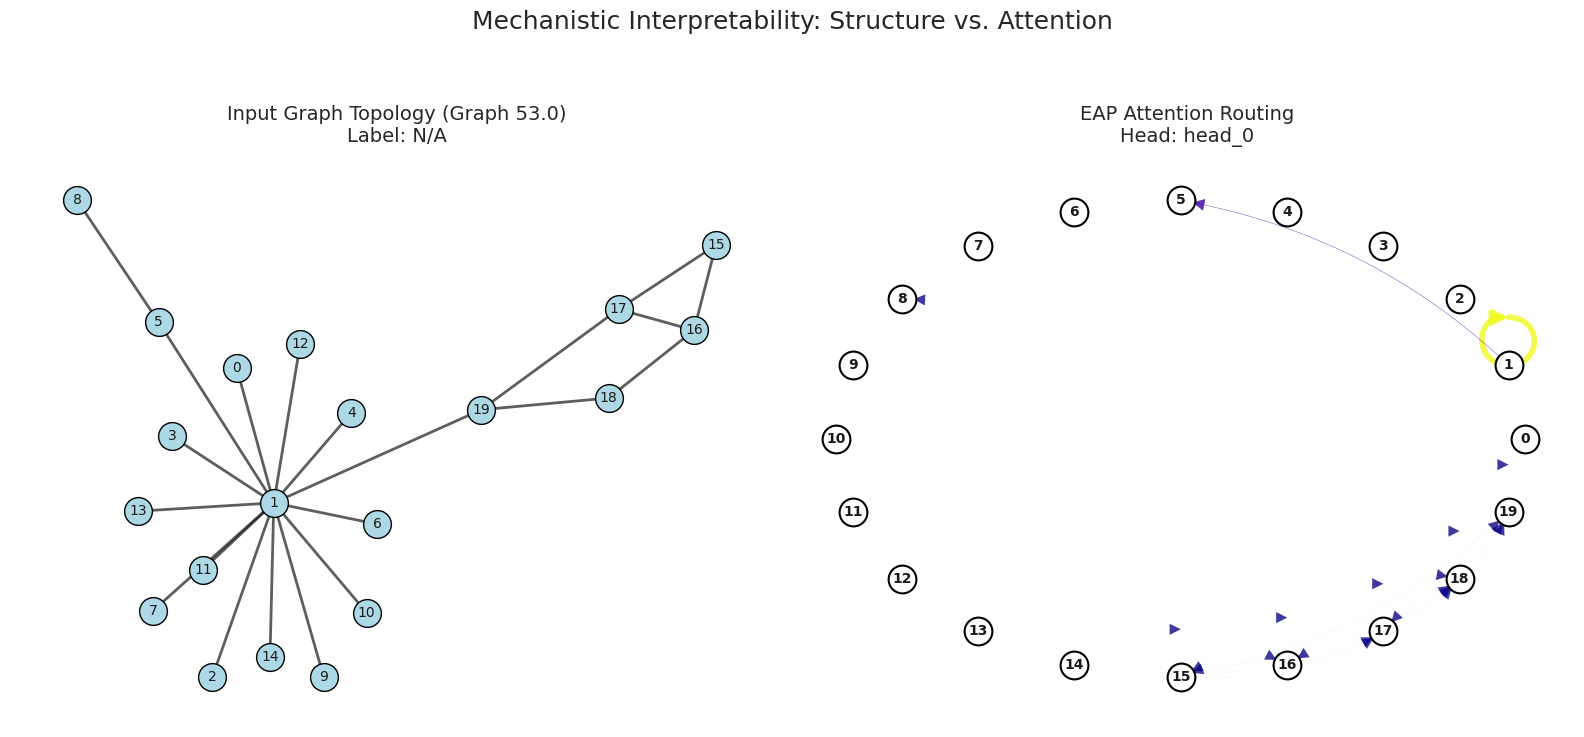

In [13]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch

# %%
# Select the single highest-scoring graph for a clear "One Row" view
if 'MPNN_Attention' in data and not df_micro.empty:
    top_g_idx = df_micro.sort_values(by='max_edge_score', ascending=False).iloc[0]['graph_index']
    micro_list_attn = data['MPNN_Attention']['micro']
    target_data = next(g for g in micro_list_attn if g['graph_index'] == top_g_idx)
    
    # --- 1. Data Preparation ---
    edge_index = target_data['edge_index'].numpy()
    label = target_data.get('y', 'N/A')
    
    # Extract the best attention head (using the keys generated in run_eap.py)
    attn_heads = {k: v for k, v in target_data['micro_scores'].items() if 'head' in k}
    best_head_key = max(attn_heads.keys(), key=lambda k: attn_heads[k].max().item())
    attn_matrix = attn_heads[best_head_key].numpy()
    num_nodes = attn_matrix.shape[0]

    # Create the Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # ---------------------------------------------------------
    # LEFT PLOT: THE PHYSICAL GRAPH (Input Structure)
    # ---------------------------------------------------------
    G_phys = nx.Graph()
    G_phys.add_nodes_from(range(num_nodes))
    for i in range(edge_index.shape[1]):
        G_phys.add_edge(edge_index[0, i], edge_index[1, i])
    
    # Spring layout shows the molecular/physical shape
    pos_phys = nx.spring_layout(G_phys, seed=42)
    
    nx.draw_networkx_nodes(G_phys, pos_phys, ax=axes[0], node_size=400, 
                           node_color='lightblue', edgecolors='black')
    nx.draw_networkx_edges(G_phys, pos_phys, ax=axes[0], width=2.0, alpha=0.7)
    nx.draw_networkx_labels(G_phys, pos_phys, ax=axes[0], font_size=10)
    
    axes[0].set_title(f"Input Graph Topology (Graph {top_g_idx})\nLabel: {label}", fontsize=14)
    axes[0].axis("off")

    # ---------------------------------------------------------
    # RIGHT PLOT: THE ATTENTION EAP (Model Interpretation)
    # ---------------------------------------------------------
    G_attn = nx.DiGraph()
    G_attn.add_nodes_from(range(num_nodes))
    
    # Threshold to show top 10% of routing connections
    threshold = np.percentile(attn_matrix[attn_matrix > 0], 90) if attn_matrix.any() else 0
    
    for u in range(num_nodes):
        for v in range(num_nodes):
            weight = attn_matrix[u, v].item()
            if weight > threshold:
                G_attn.add_edge(u, v, weight=weight)
    
    # Circular layout makes it clear how information flows between nodes
    pos_attn = nx.circular_layout(G_attn)
    
    # Draw nodes and labels
    nx.draw_networkx_nodes(G_attn, pos_attn, ax=axes[1], node_size=400, 
                           node_color='white', edgecolors='black', linewidths=1.5)
    nx.draw_networkx_labels(G_attn, pos_attn, ax=axes[1], font_size=10, font_weight='bold')
    
    # Draw edges with Plasma colormap (Yellow = High Attribution)
    weights = [G_attn[u][v]['weight'] for u, v in G_attn.edges()]
    if weights:
        max_w = max(weights)
        edge_colors = [plt.cm.plasma(w / max_w) for w in weights]
        
        nx.draw_networkx_edges(
            G_attn, pos_attn, ax=axes[1],
            width=[(w/max_w)*4 for w in weights],
            edge_color=edge_colors,
            connectionstyle="arc3,rad=0.15", # Curved for bidirectional visibility
            arrowsize=20,
            alpha=0.8
        )

    axes[1].set_title(f"EAP Attention Routing\nHead: {best_head_key.split('.')[-1]}", fontsize=14)
    axes[1].axis("off")

    plt.suptitle(f"Mechanistic Interpretability: Structure vs. Attention", fontsize=18, y=1.05)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_17240/4167832469.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


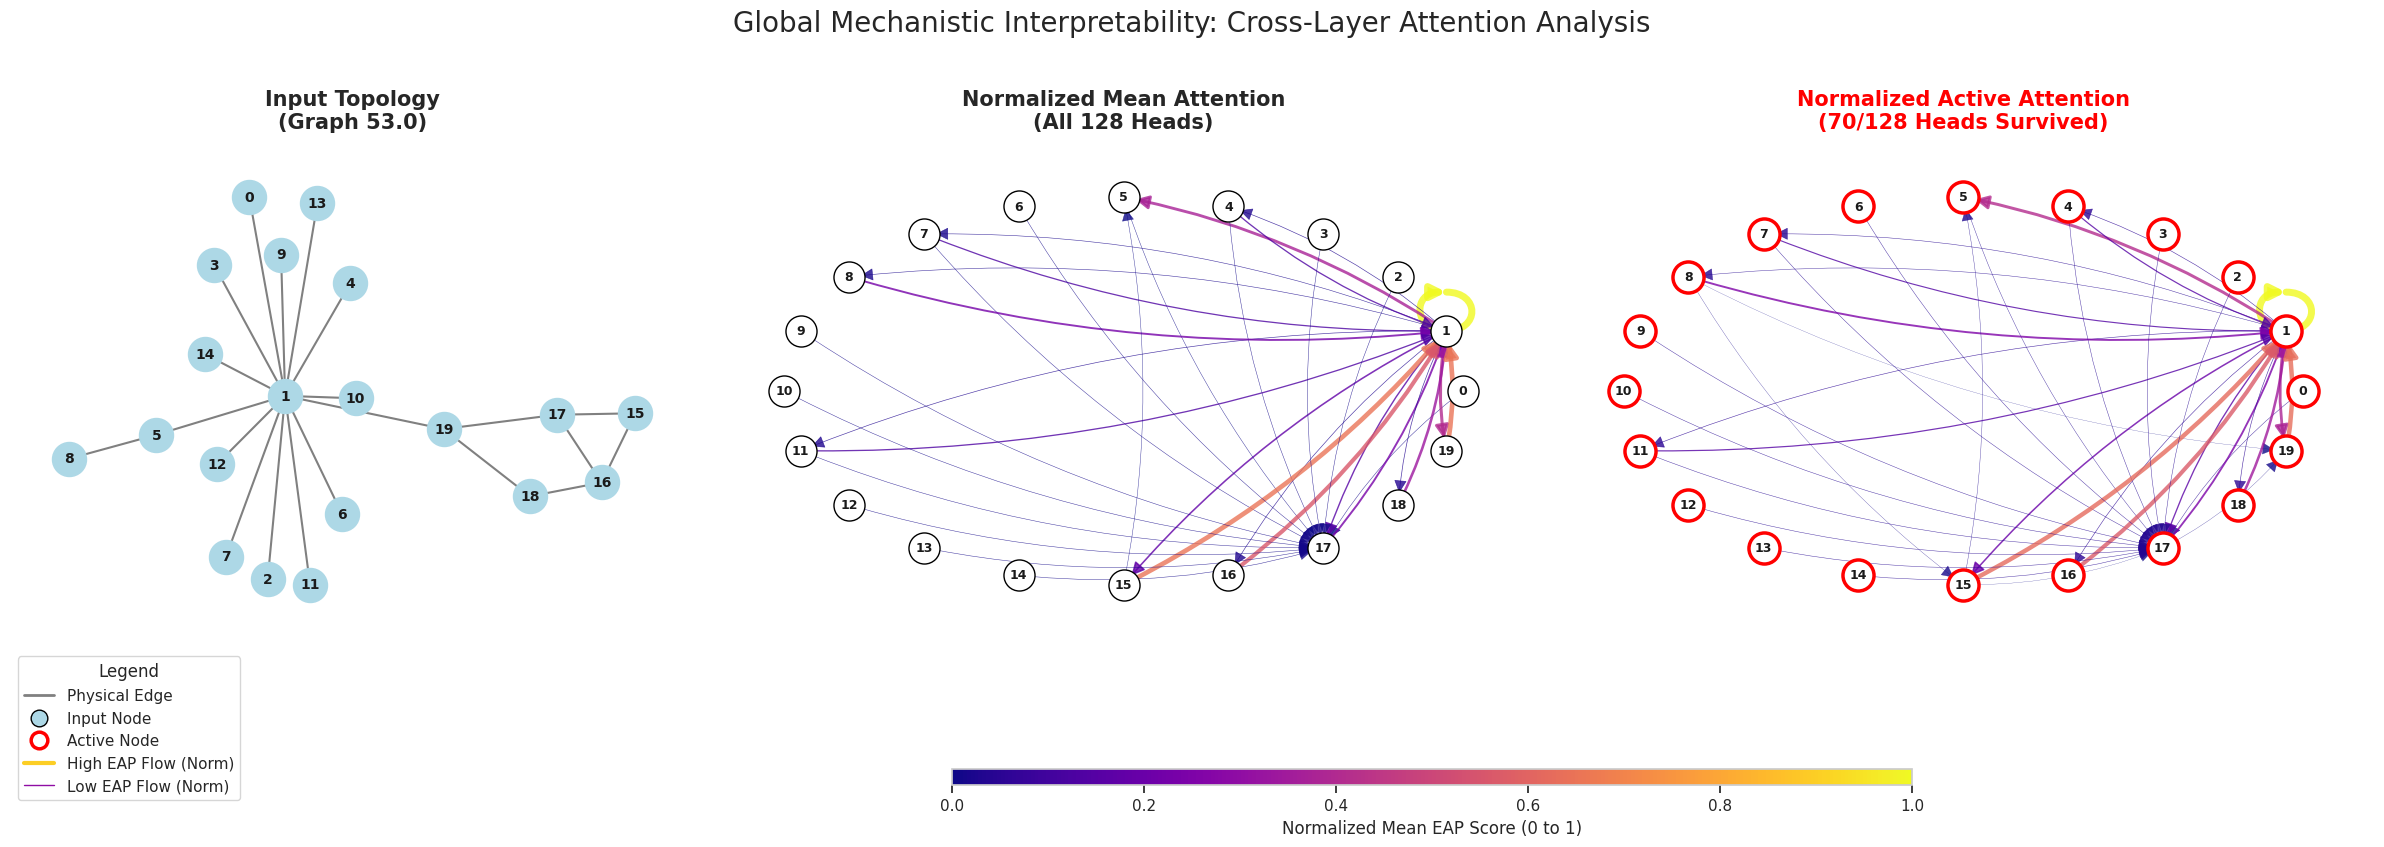

In [14]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import torch
from matplotlib.lines import Line2D

# %%
RUN_NAME = 'MPNN_Attention'

if RUN_NAME in data and not df_micro.empty:
    # 1. Selection: Pick the top-scoring graph
    top_g_idx = df_micro.sort_values(by='max_edge_score', ascending=False).iloc[0]['graph_index']
    run_data = data[RUN_NAME]
    target_data = next(g for g in run_data['micro'] if g['graph_index'] == top_g_idx)
    masks = run_data.get('masks', {})
    
    # 2. Global Aggregation across ALL Layers & ALL Heads
    all_head_tensors = []
    active_head_tensors = []
    
    # head_keys are like 'layers.0.attn.M.head_0', 'layers.1.attn.M.head_3', etc.
    head_keys = [k for k in target_data['micro_scores'].keys() if 'head' in k]
    
    for k in head_keys:
        attn_matrix = target_data['micro_scores'][k].numpy()
        all_head_tensors.append(attn_matrix)
        
        # Check Mask status for this specific head
        mask_val = masks.get(k, 0)
        is_active = (mask_val > 0).any().item() if isinstance(mask_val, torch.Tensor) else mask_val > 0
        
        if is_active:
            active_head_tensors.append(attn_matrix)

    # 3. Calculate Means
    mean_all = np.mean(all_head_tensors, axis=0) if all_head_tensors else np.zeros((20, 20))
    mean_active = np.mean(active_head_tensors, axis=0) if active_head_tensors else np.zeros_like(mean_all)
    num_nodes = mean_all.shape[0]

    # 4. Normalization Logic
    # We normalize to [0, 1] range to ensure colorbars and widths are comparable and readable
    def normalize_matrix(mat):
        m_min, m_max = mat.min(), mat.max()
        if m_max - m_min > 1e-9:
            return (mat - m_min) / (m_max - m_min)
        return mat

    norm_all = normalize_matrix(mean_all)
    norm_active = normalize_matrix(mean_active)

    # 5. Visualization Setup
    fig, axes = plt.subplots(1, 3, figsize=(24, 8), gridspec_kw={'width_ratios': [1, 1.2, 1.2]})
    pos_circ = nx.circular_layout(range(num_nodes))
    cmap = plt.cm.plasma

    # --- COL 1: PHYSICAL STRUCTURE ---
    G_phys = nx.Graph()
    edge_index = target_data['edge_index'].numpy()
    for i in range(edge_index.shape[1]):
        G_phys.add_edge(edge_index[0, i], edge_index[1, i])
    
    pos_phys = nx.spring_layout(G_phys, seed=42)
    nx.draw(G_phys, pos_phys, ax=axes[0], with_labels=True, node_color='lightblue', 
            edge_color='gray', width=1.5, node_size=600, font_size=10, font_weight='bold')
    axes[0].set_title(f"Input Topology\n(Graph {top_g_idx})", fontsize=15, fontweight='bold', pad=20)

    # --- COL 2: NORMALIZED GLOBAL MEAN (ALL HEADS) ---
    G_all = nx.DiGraph()
    # Thresholding at 90th percentile of the normalized values to show main pathways
    thresh_all = np.percentile(norm_all, 90)
    for u in range(num_nodes):
        for v in range(num_nodes):
            if norm_all[u,v] > thresh_all: 
                G_all.add_edge(u, v, weight=norm_all[u,v])
    
    nx.draw_networkx_nodes(G_all, pos_circ, ax=axes[1], node_size=500, node_color='white', edgecolors='black')
    nx.draw_networkx_labels(G_all, pos_circ, ax=axes[1], font_size=9, font_weight='bold')
    
    weights_all = [G_all[u][v]['weight'] for u, v in G_all.edges()]
    if weights_all:
        nx.draw_networkx_edges(G_all, pos_circ, ax=axes[1], edge_color=weights_all, 
                               edge_cmap=cmap, width=[w*5 for w in weights_all], 
                               connectionstyle="arc3,rad=0.1", arrowsize=20, alpha=0.8)
    axes[1].set_title(f"Normalized Mean Attention\n(All {len(all_head_tensors)} Heads)", fontsize=15, fontweight='bold', pad=20)

    # --- COL 3: NORMALIZED GLOBAL ACTIVE (MASKED) ---
    G_act = nx.DiGraph()
    thresh_act = np.percentile(norm_active, 90) if norm_active.any() else 0
    for u in range(num_nodes):
        for v in range(num_nodes):
            if norm_active[u,v] > thresh_act: 
                G_act.add_edge(u, v, weight=norm_active[u,v])
    
    nx.draw_networkx_nodes(G_act, pos_circ, ax=axes[2], node_size=500, node_color='white', edgecolors='red', linewidths=2.5)
    nx.draw_networkx_labels(G_act, pos_circ, ax=axes[2], font_size=9, font_weight='bold')
    
    weights_act = [G_act[u][v]['weight'] for u, v in G_act.edges()]
    if weights_act:
        nx.draw_networkx_edges(G_act, pos_circ, ax=axes[2], edge_color=weights_act, 
                               edge_cmap=cmap, width=[w*5 for w in weights_act], 
                               connectionstyle="arc3,rad=0.1", arrowsize=20, alpha=0.8)
    
    survivors = f"{len(active_head_tensors)}/{len(all_head_tensors)}"
    axes[2].set_title(f"Normalized Active Attention\n({survivors} Heads Survived)", fontsize=15, fontweight='bold', color='red', pad=20)

    # --- ENHANCED LEGEND ---
    legend_elements = [
        Line2D([0], [0], color='gray', lw=2, label='Physical Edge'),
        Line2D([0], [0], marker='o', color='w', label='Input Node', markerfacecolor='lightblue', markersize=12, markeredgecolor='black'),
        Line2D([0], [0], marker='o', color='w', label='Active Node', markerfacecolor='white', markersize=12, markeredgecolor='red', markeredgewidth=2.5),
        Line2D([0], [0], color=cmap(0.9), lw=3, label='High EAP Flow (Norm)'),
        Line2D([0], [0], color=cmap(0.3), lw=1, label='Low EAP Flow (Norm)')
    ]
    axes[0].legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0, -0.05), fontsize=11, frameon=True, title="Legend")

    # Shared Colorbar for Normalized Attention
    sm = plt.cm.ScalarMappable(norm=plt.Normalize(vmin=0, vmax=1), cmap=cmap)
    cbar_ax = fig.add_axes([0.4, 0.05, 0.4, 0.02])
    fig.colorbar(sm, cax=cbar_ax, orientation='horizontal', label='Normalized Mean EAP Score (0 to 1)')

    for ax in axes: ax.axis('off')
    plt.suptitle(f"Global Mechanistic Interpretability: Cross-Layer Attention Analysis", fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

In [15]:
# Grab the top graph's data again
top_g_idx = df_micro.sort_values(by='max_edge_score', ascending=False).iloc[0]['graph_index']
target_data = next(g for g in data['MPNN_Attention']['micro'] if g['graph_index'] == top_g_idx)

print("--- ALL KEYS IN MICRO_SCORES ---")
for k, v in target_data['micro_scores'].items():
    print(f"Key: '{k}'  -->  Shape: {v.shape}")

--- ALL KEYS IN MICRO_SCORES ---
Key: 'layers.0.conv.M'  -->  Shape: torch.Size([42])
Key: 'layers.0.attn.M.head_0'  -->  Shape: torch.Size([20, 20])
Key: 'layers.0.attn.M.head_1'  -->  Shape: torch.Size([20, 20])
Key: 'layers.0.attn.M.head_2'  -->  Shape: torch.Size([20, 20])
Key: 'layers.0.attn.M.head_3'  -->  Shape: torch.Size([20, 20])
Key: 'layers.0.attn.M.head_4'  -->  Shape: torch.Size([20, 20])
Key: 'layers.0.attn.M.head_5'  -->  Shape: torch.Size([20, 20])
Key: 'layers.0.attn.M.head_6'  -->  Shape: torch.Size([20, 20])
Key: 'layers.0.attn.M.head_7'  -->  Shape: torch.Size([20, 20])
Key: 'layers.1.conv.M'  -->  Shape: torch.Size([42])
Key: 'layers.1.attn.M.head_0'  -->  Shape: torch.Size([20, 20])
Key: 'layers.1.attn.M.head_1'  -->  Shape: torch.Size([20, 20])
Key: 'layers.1.attn.M.head_2'  -->  Shape: torch.Size([20, 20])
Key: 'layers.1.attn.M.head_3'  -->  Shape: torch.Size([20, 20])
Key: 'layers.1.attn.M.head_4'  -->  Shape: torch.Size([20, 20])
Key: 'layers.1.attn.M.head_5'

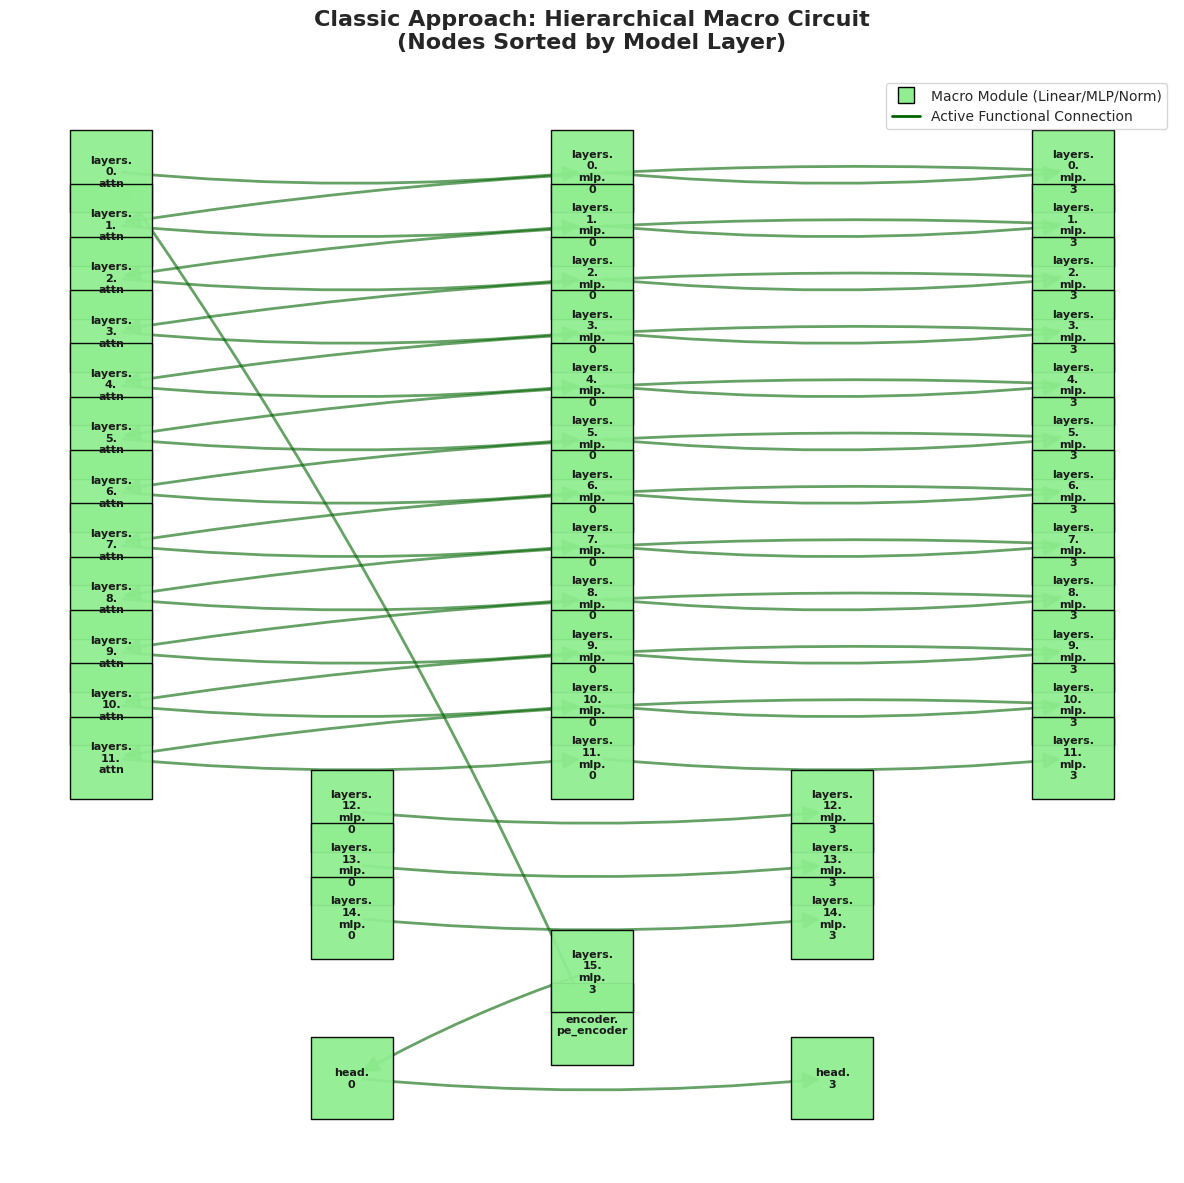

In [21]:
import pickle
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# 1. Load the Classic Macro Circuit
# This assumes the file is in your current directory or path
pkl_path = "../outputs/eap_results/ba_shapes/graphgps/classic/optimal_macro_circuit.pkl"

try:
    with open(pkl_path, 'rb') as f:
        G = pickle.load(f)
except FileNotFoundError:
    print(f"Error: {pkl_path} not found. Please ensure the file exists.")
    G = None
if G:
    # 2. Logic to sort by Layer
    def get_layer_rank(node_name):
        # Extract layer index (e.g., 'layers.0.mlp' -> 0)
        layer_match = re.search(r'layers\.(\d+)', node_name)
        if layer_match:
            return int(layer_match.group(1))
        # Logic for pre/post processing
        if 'embedding' in node_name.lower() or 'input' in node_name.lower():
            return -1
        if 'head' in node_name.lower() or 'classifier' in node_name.lower():
            return 999
        return 50  # Default for middle components

    # Group nodes by their layer rank
    nodes = list(G.nodes())
    layer_map = {}
    for n in nodes:
        rank = get_layer_rank(n)
        if rank not in layer_map:
            layer_map[rank] = []
        layer_map[rank].append(n)

    # 3. Create Layered Layout (Multipartite-style)
    pos = {}
    sorted_ranks = sorted(layer_map.keys())
    for i, rank in enumerate(sorted_ranks):
        nodes_in_layer = sorted(layer_map[rank]) # Alphabetical sort within layer
        n_count = len(nodes_in_layer)
        for j, node in enumerate(nodes_in_layer):
            # X-coordinate: centered
            # Y-coordinate: top to bottom based on layer index
            pos[node] = (j - (n_count - 1) / 2.0, -i)

    # 4. Visualization
    plt.figure(figsize=(12, 12))
    
    # Draw Nodes
    nx.draw_networkx_nodes(G, pos, node_size=3500, node_color='lightgreen', 
                           edgecolors='black', node_shape='s', alpha=0.95)
    
    # Draw Node Labels (wrapped for readability)
    labels = {n: n.replace('.', '.\n') for n in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_weight='bold')

    # Draw Edges (Binary/Uniform as requested)
    # No EAP weight scaling - just showing existence of connection
    nx.draw_networkx_edges(G, pos, width=2.0, edge_color='darkgreen', 
                           arrowsize=25, connectionstyle="arc3,rad=0.05", alpha=0.6)

    # 5. Legend
    legend_elements = [
        Line2D([0], [0], marker='s', color='w', label='Macro Module (Linear/MLP/Norm)', 
               markerfacecolor='lightgreen', markersize=12, markeredgecolor='black'),
        Line2D([0], [0], color='darkgreen', lw=2, label='Active Functional Connection')
    ]
    plt.legend(handles=legend_elements, loc='upper right', frameon=True, fontsize=10)

    plt.title("Classic Approach: Hierarchical Macro Circuit\n(Nodes Sorted by Model Layer)", 
              fontsize=16, fontweight='bold', pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()